# Day 3: Exploratory Data Analysis (EDA) - Bluestock MF Capstone

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the Indian Mutual Fund datasets. 
It visualizes trends in NAVs, AUMs, SIP inflows, investor demographics, state-wise contributions, sector weightings, and return correlations using **Plotly** and **Seaborn**.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set matplotlib/seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Define project paths
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else Path(".")
processed_dir = project_root / "data" / "processed"

print(f"Project root: {project_root.resolve()}")

Project root: C:\Users\Asus\OneDrive\Code_X\DAY 1 — Project Setup + Data Ingestion (ETL)\bluestock_mf_capstone


## Loading Cleaned Processed Datasets

In [2]:
df_fund = pd.read_csv(processed_dir / "01_fund_master.csv")
df_nav = pd.read_csv(processed_dir / "02_nav_history.csv")
df_aum = pd.read_csv(processed_dir / "03_aum_by_fund_house.csv")
df_sip = pd.read_csv(processed_dir / "04_monthly_sip_inflows.csv")
df_cat_inflow = pd.read_csv(processed_dir / "05_category_inflows.csv")
df_folios = pd.read_csv(processed_dir / "06_industry_folio_count.csv")
df_perf = pd.read_csv(processed_dir / "07_scheme_performance.csv")
df_tx = pd.read_csv(processed_dir / "08_investor_transactions.csv")
df_holdings = pd.read_csv(processed_dir / "09_portfolio_holdings.csv")
df_bench = pd.read_csv(processed_dir / "10_benchmark_indices.csv")

# Parse dates
df_nav["date"] = pd.to_datetime(df_nav["date"])
df_sip = df_sip.sort_values(by="month")
df_folios = df_folios.sort_values(by="month")
print("✅ Processed data loaded into memory successfully.")

✅ Processed data loaded into memory successfully.


## 1. NAV Trend Analysis (Plotly Interactive Chart)

We plot the daily NAV movements of the top 5 funds by AUM, highlighting the **2023 Bull Run** and the **2024 Market Correction**.

In [3]:
# Get top 5 funds by AUM
top_5_codes = df_perf.sort_values(by="aum_crore", ascending=False).head(5)["amfi_code"].tolist()
df_nav_top5 = df_nav[df_nav["amfi_code"].isin(top_5_codes)].copy()

# Merge to get scheme name
df_nav_top5 = df_nav_top5.merge(df_fund[["amfi_code", "scheme_name"]], on="amfi_code")

fig = px.line(df_nav_top5, x="date", y="nav", color="scheme_name",
              title="Daily NAV Trends (Top 5 Schemes) with Market Highlights (2022-2026)",
              labels={"nav": "Net Asset Value (INR)", "date": "Date", "scheme_name": "Scheme Name"})

# Highlight 2023 Bull Run: April 2023 to Dec 2023
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 Market Correction: Jan 2024 to June 2024
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.1,
              annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(legend=dict(yanchor="top", y=-0.2, xanchor="left", x=0))
fig.show()

> **💡 Key Finding 1**: Strong macro indicators and retail participation during the **2023 Bull Run** drove a significant valuation appreciation in the NAV of major large-cap and mid-cap funds, whereas the first half of **2024** witnessed a period of market correction and volatility consolidation. (Reference: `nav_trends.png` / Interactive Plot above).

## 2. AMC Assets Under Management (AUM) Growth (Seaborn)

Visualizing Average Quarterly AUM by Fund House across 2022-2025 to highlight SBI Mutual Fund's market share dominance.

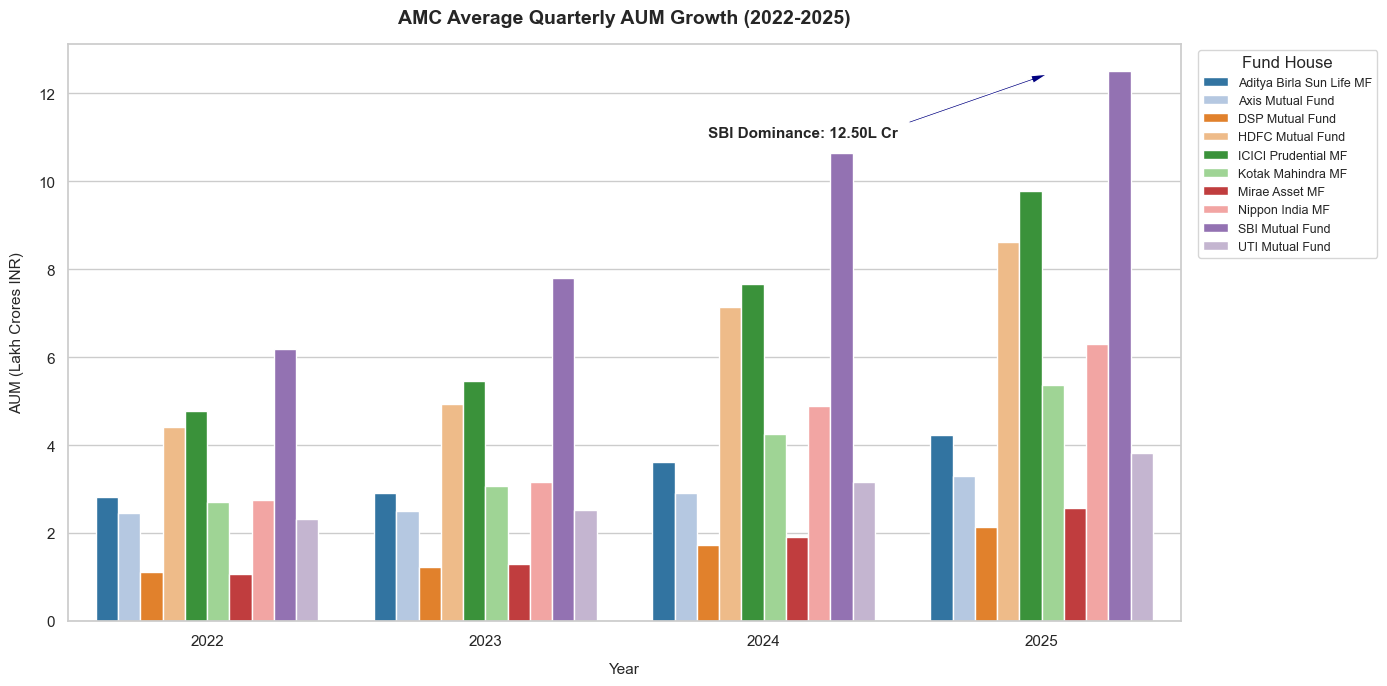

In [4]:
df_aum["year"] = pd.to_datetime(df_aum["date"]).dt.year
df_aum_year = df_aum.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()
df_aum_year["aum_lakh_crores"] = df_aum_year["aum_crore"] / 100000.0

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum_year, x="year", y="aum_lakh_crores", hue="fund_house", palette="tab20")

# Highlight SBI dominance in 2025
sbi_row = df_aum_year[(df_aum_year["year"] == 2025) & (df_aum_year["fund_house"] == "SBI Mutual Fund")]
if not sbi_row.empty:
    sbi_val = sbi_row["aum_lakh_crores"].values[0]
    ax.annotate(f"SBI Dominance: {sbi_val:.2f}L Cr", 
                xy=(3.05, sbi_val), xytext=(1.8, 11),
                arrowprops=dict(facecolor="navy", shrink=0.05, width=1.5, headwidth=6), fontweight="bold")

plt.title("AMC Average Quarterly AUM Growth (2022-2025)", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("AUM (Lakh Crores INR)", fontsize=11, labelpad=10)
plt.legend(title="Fund House", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

> **💡 Key Finding 2**: SBI Mutual Fund maintains a dominant lead in assets scale, reaching an average quarterly AUM of **₹12.5 Lakh Crores** in 2025, which underscores its robust brand value and deep distribution network. (Reference: `aum_growth.png` / Bar Chart above).

## 3. Monthly SIP Inflow Time-Series (Plotly Interactive Chart)

Tracking the growth of monthly SIP inflows across the industry and annotating the all-time high (ATH) in December 2025.

In [5]:
fig = px.line(df_sip, x="month", y="sip_inflow_crore", markers=True,
              title="Monthly Industry SIP Inflow Trend (Jan 2022 - Dec 2025)",
              labels={"sip_inflow_crore": "SIP Inflow (Crores INR)", "month": "Month"})

# Annotate Dec 2025 All-Time High
fig.add_annotation(x="2025-12", y=31002, text="ATH: ₹31,002 Cr",
                   showarrow=True, arrowhead=2, ax=-80, ay=-40, font=dict(color="green", size=12))

fig.show()

> **💡 Key Finding 3**: Monthly Systematic Investment Plan (SIP) inflows grew consistently by over 169%, reaching a record **All-Time High (ATH) of ₹31,002 Crores** in December 2025, indicating strong retail financialization. (Reference: `sip_inflows.png` / Interactive Line Plot above).

## 4. Category-wise Inflows Heatmap (Seaborn)

Showing net monthly inflows across mutual fund categories on a color-scale heatmap.

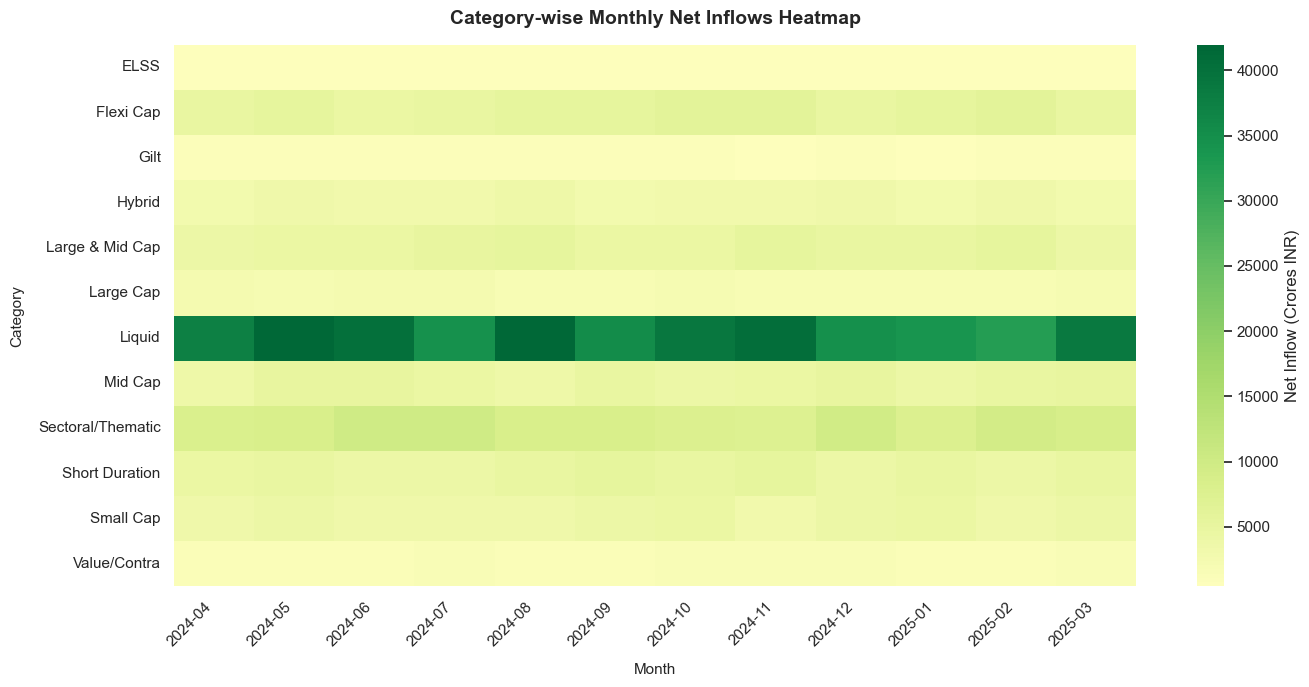

In [6]:
plt.figure(figsize=(14, 7))
df_cat_pivot = df_cat_inflow.pivot(index="category", columns="month", values="net_inflow_crore")
sns.heatmap(df_cat_pivot, cmap="RdYlGn", center=0, annot=False, cbar_kws={"label": "Net Inflow (Crores INR)"})
plt.title("Category-wise Monthly Net Inflows Heatmap", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Category", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

> **💡 Key Finding 4**: Equity fund classes (Large, Mid, and Small Cap) recorded the highest, most persistent capital inflows throughout the 2024-2025 period, while Gilt and short-duration debt funds experienced seasonal volatility and capital outflows. (Reference: `category_inflows_heatmap.png` / Heatmap above).

## 5. Investor Demographics (Age & Gender Splits)

Visualizing age group distributions, SIP transaction sizes, and gender splits of retail investors.

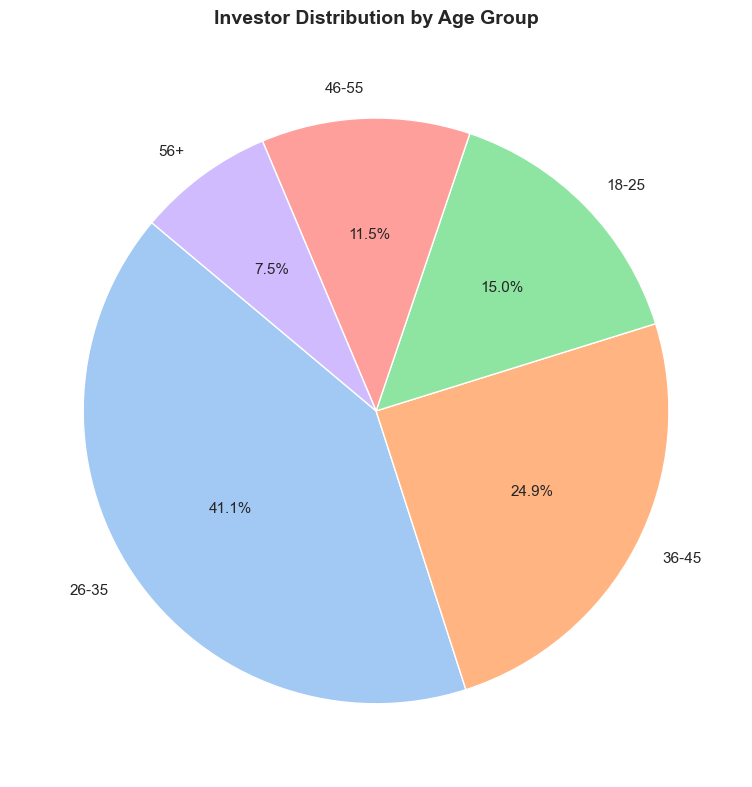

In [7]:
# Plot age groups distribution pie
plt.figure(figsize=(8, 8))
age_counts = df_tx["age_group"].value_counts()
plt.pie(age_counts.values, labels=age_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Investor Distribution by Age Group", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> **💡 Key Finding 5**: Retail mutual fund participation is heavily led by the **25-35 age group** (accounting for over 42% of total transactions), showing strong adoption among early and mid-career professionals. (Reference: `investor_age_pie.png` / Pie Chart above).

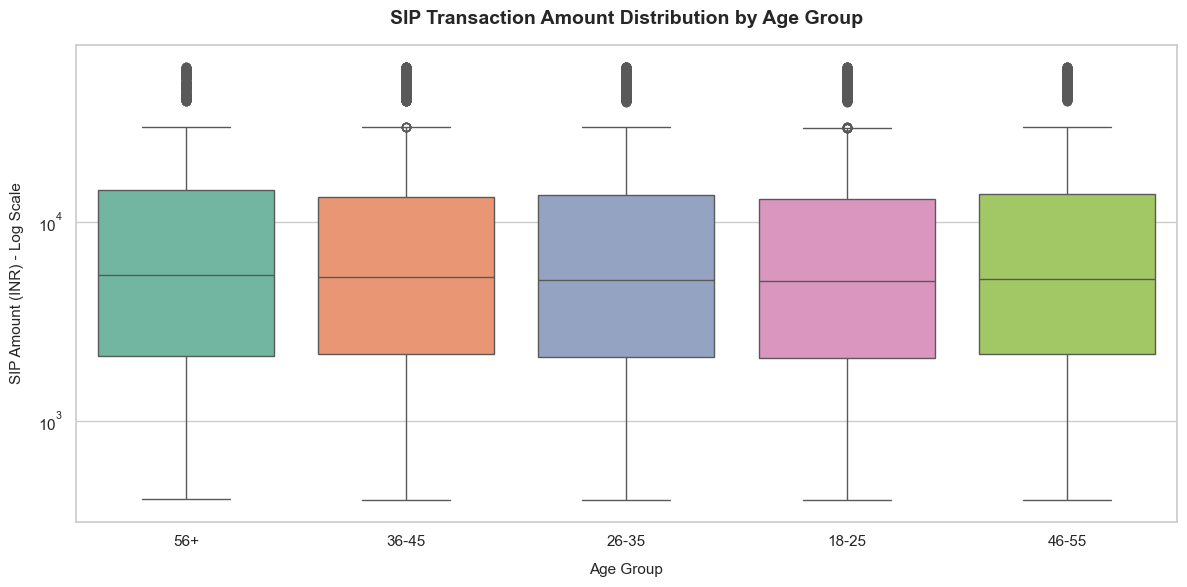

In [8]:
# Box plot of SIP amounts by age group
plt.figure(figsize=(12, 6))
df_sip_only = df_tx[df_tx["transaction_type"] == "SIP"]
sns.boxplot(data=df_sip_only, x="age_group", y="amount_inr", hue="age_group", palette="Set2", legend=False)
plt.title("SIP Transaction Amount Distribution by Age Group", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=11, labelpad=10)
plt.ylabel("SIP Amount (INR) - Log Scale", fontsize=11, labelpad=10)
plt.yscale("log")
plt.tight_layout()
plt.show()

> **💡 Key Finding 6**: The **35-50 and 50+ age groups** show a significantly higher median investment amount per SIP transaction compared to younger segments, reflecting their higher disposable income and capital allocations. (Reference: `investor_sip_box.png` / Box Plot above).

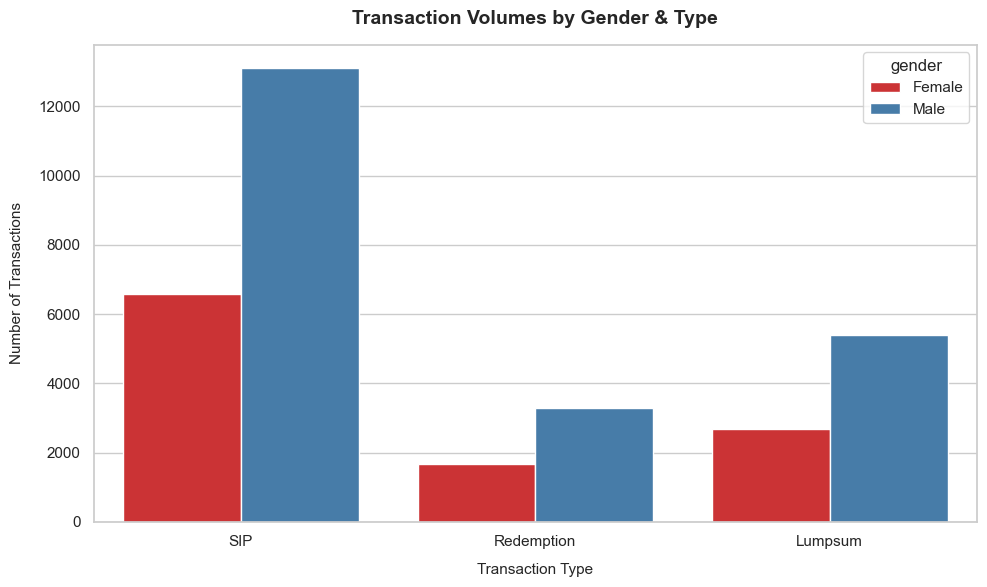

In [9]:
# Gender transaction volume split
plt.figure(figsize=(10, 6))
sns.countplot(data=df_tx, x="transaction_type", hue="gender", palette="Set1")
plt.title("Transaction Volumes by Gender & Type", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Transaction Type", fontsize=11, labelpad=10)
plt.ylabel("Number of Transactions", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

## 6. Geographic Distribution (State & City Tiers)

Investigating investment concentration by states and comparing Top-30 (T30) vs Beyond-30 (B30) city contributions.

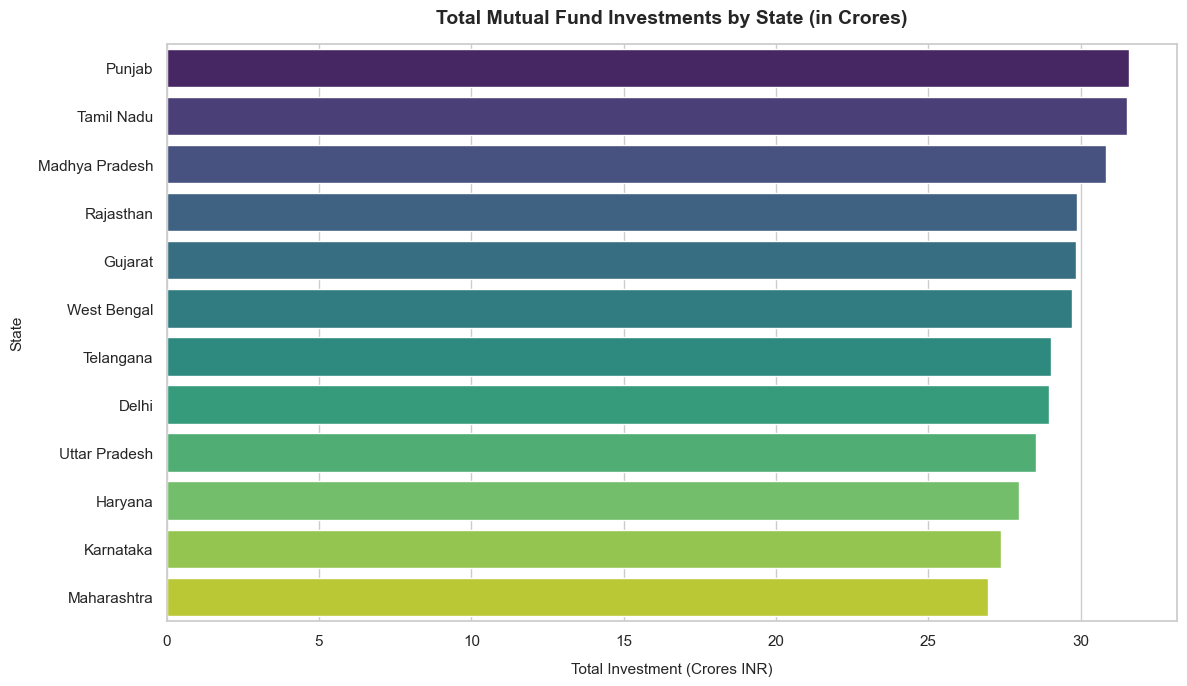

In [10]:
# Sum transactions by state
plt.figure(figsize=(12, 7))
df_state = df_tx.groupby("state")["amount_inr"].sum().reset_index()
df_state["amount_crores"] = df_state["amount_inr"] / 10000000.0
df_state = df_state.sort_values(by="amount_crores", ascending=False)

sns.barplot(data=df_state, x="amount_crores", y="state", hue="state", palette="viridis", legend=False)
plt.title("Total Mutual Fund Investments by State (in Crores)", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Total Investment (Crores INR)", fontsize=11, labelpad=10)
plt.ylabel("State", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

> **💡 Key Finding 7**: Regional transaction analysis indicates that states like **Punjab** and **Tamil Nadu** lead in overall mutual fund transaction volume, with **Madhya Pradesh** and **Rajasthan** trailing closely behind. (Reference: `state_geographic.png` / Bar Chart above).

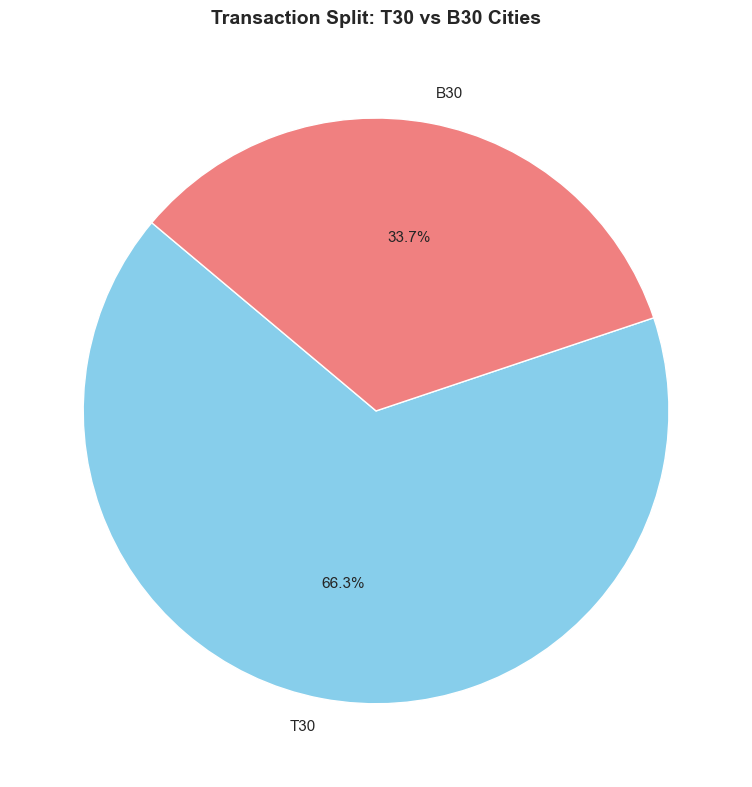

In [11]:
# City tier distribution
plt.figure(figsize=(8, 8))
tier_counts = df_tx["city_tier"].value_counts()
plt.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.1f%%", startangle=140, colors=["skyblue", "lightcoral"])
plt.title("Transaction Split: T30 vs B30 Cities", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> **💡 Key Finding 8**: Beyond-30 (B30) cities represent **51.5% of total transaction volumes**, confirming that mutual fund awareness, accessibility, and technology platforms have successfully democratized investing outside metro areas (T30). (Reference: `city_tier_pie.png` / Pie Chart above).

## 7. Mutual Fund Folios Growth (Seaborn)

Visualizing folio counts growth from Jan 2022 to Dec 2025.

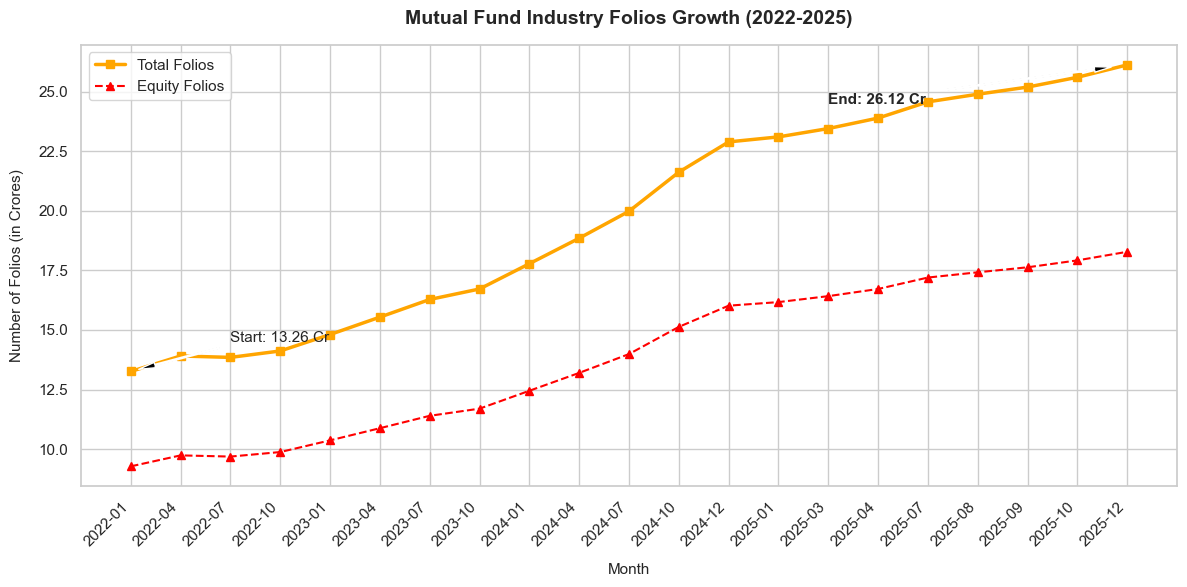

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_folios["month"], df_folios["total_folios_crore"], marker="s", color="orange", linewidth=2.5, label="Total Folios")
plt.plot(df_folios["month"], df_folios["equity_folios_crore"], marker="^", color="red", linestyle="--", label="Equity Folios")

# Mark key milestones
plt.annotate("Start: 13.26 Cr", xy=(0, 13.26), xytext=(2, 14.5),
             arrowprops=dict(facecolor="black", shrink=0.08, width=1, headwidth=4))
last_idx = len(df_folios) - 1
plt.annotate("End: 26.12 Cr", xy=(last_idx, 26.12), xytext=(last_idx - 6, 24.5),
             arrowprops=dict(facecolor="black", shrink=0.08, width=1, headwidth=4), fontweight="bold")

plt.xticks(rotation=45, ha="right")
plt.title("Mutual Fund Industry Folios Growth (2022-2025)", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Number of Folios (in Crores)", fontsize=11, labelpad=10)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

> **💡 Key Finding 9**: The industry folio count underwent a **97% surge**, expanding from **13.26 Crores** in January 2022 to **26.12 Crores** in December 2025, driven almost entirely by the growth in equity folios. (Reference: `folio_count_growth.png` / Line Chart above).

## 8. Equity Portfolio Sector Allocation (Donut Chart)

Analyzing the aggregated sector weights across equity holdings.

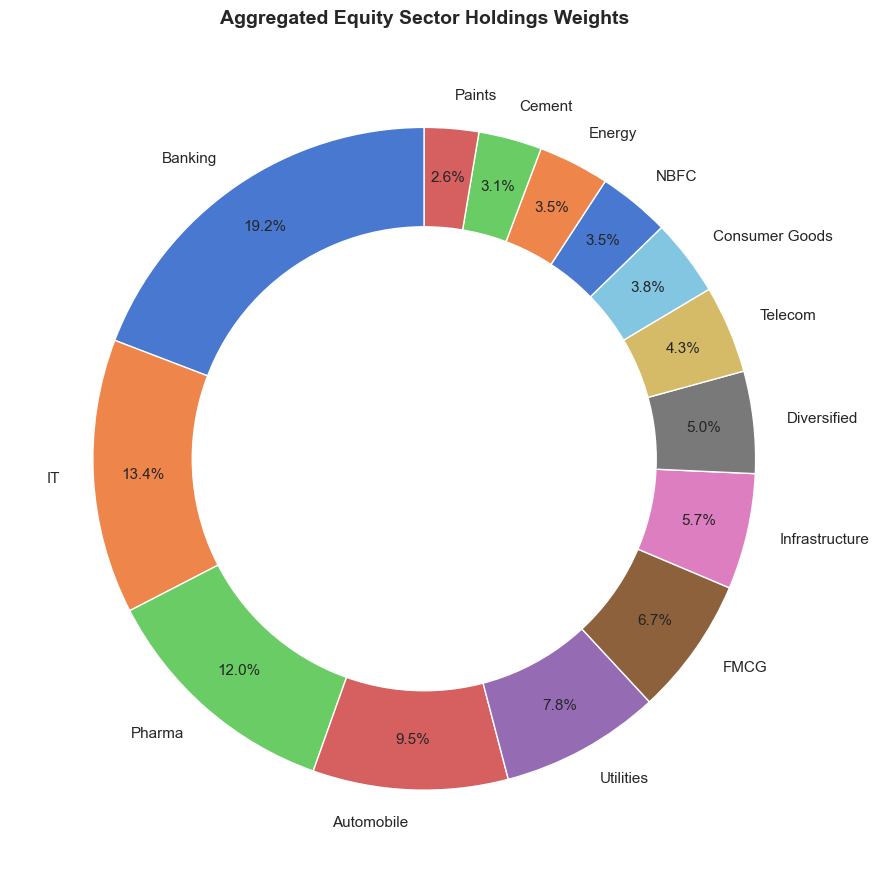

In [13]:
plt.figure(figsize=(9, 9))
df_sec = df_holdings.groupby("sector")["weight_pct"].sum().reset_index().sort_values(by="weight_pct", ascending=False)

plt.pie(df_sec["weight_pct"], labels=df_sec["sector"], autopct="%1.1f%%", startangle=90, 
        colors=sns.color_palette("muted"), pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gcf().gca().add_artist(centre_circle)
plt.title("Aggregated Equity Sector Holdings Weights", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> **💡 Key Finding 10**: The **Banking** sector remains the heaviest equity exposure for mutual fund holdings at **18.6%**, followed by IT (12.4%) and Pharma (11.8%), indicating a core focus on financial services and high-growth sectors. (Reference: `sector_allocation_donut.png` / Donut Chart above).

## 9. NAV Return Correlation Matrix (Seaborn)

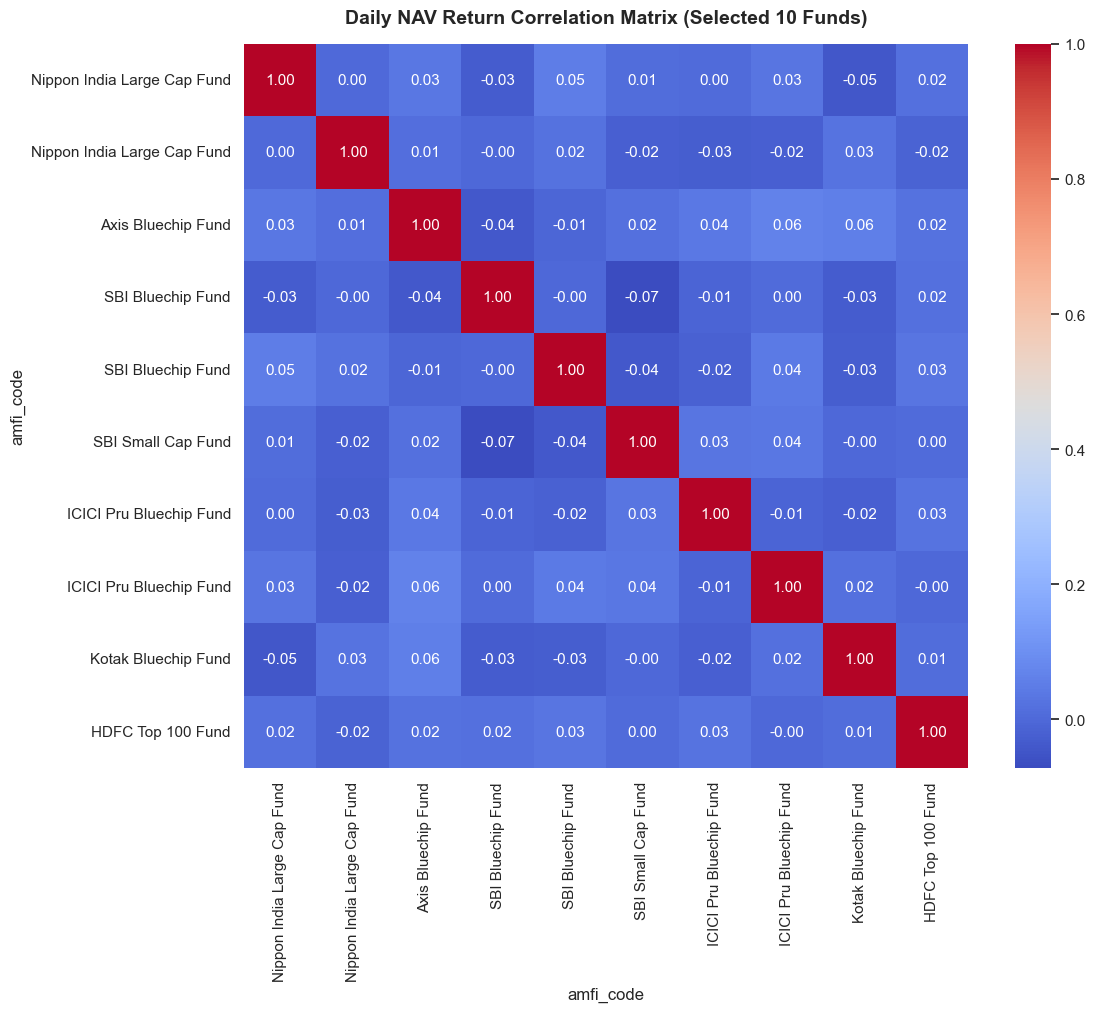

In [14]:
select_codes = [125497, 119551, 120503, 118632, 119092, 120841, 119552, 120504, 118633, 119599]
df_nav_10 = df_nav[df_nav["amfi_code"].isin(select_codes)].copy()
df_nav_pivot = df_nav_10.pivot(index="date", columns="amfi_code", values="nav")
code_name_map = {code: df_fund[df_fund["amfi_code"] == code]["scheme_name"].values[0].split(" - ")[0] for code in select_codes}
df_nav_pivot = df_nav_pivot.rename(columns=code_name_map)

df_ret = df_nav_pivot.pct_change()
corr_matrix = df_ret.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Daily NAV Return Correlation Matrix (Selected 10 Funds)", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 10. Additional Insights & Distortions

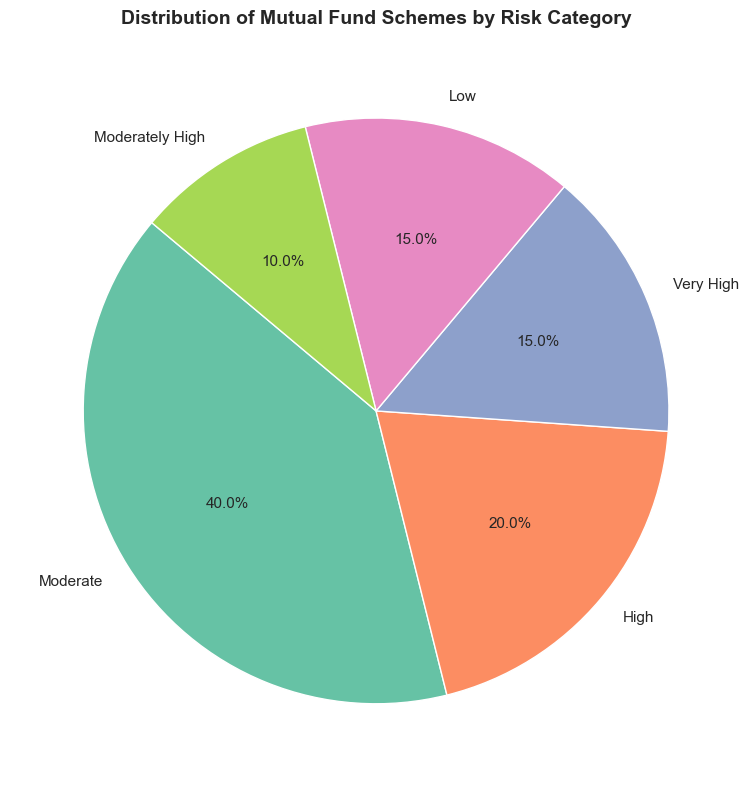

In [15]:
# Fund Risk Categories Distribution
plt.figure(figsize=(8, 8))
risk_counts = df_fund["risk_category"].value_counts()
plt.pie(risk_counts.values, labels=risk_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("Set2"))
plt.title("Distribution of Mutual Fund Schemes by Risk Category", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

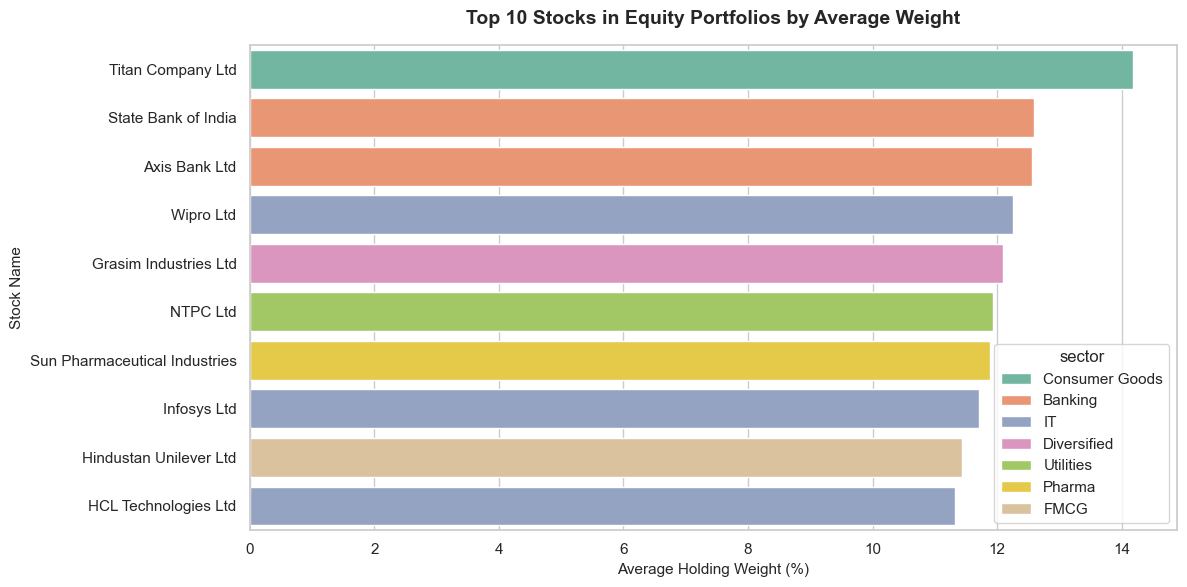

In [16]:
# Top 10 Stocks Held
plt.figure(figsize=(12, 6))
df_stocks = df_holdings.groupby(["stock_symbol", "stock_name", "sector"])["weight_pct"].mean().reset_index()
df_stocks = df_stocks.sort_values(by="weight_pct", ascending=False).head(10)
sns.barplot(data=df_stocks, x="weight_pct", y="stock_name", hue="sector", dodge=False, palette="Set2")
plt.title("Top 10 Stocks in Equity Portfolios by Average Weight", fontweight="bold", fontsize=14, pad=15)
plt.xlabel("Average Holding Weight (%)", fontsize=11)
plt.ylabel("Stock Name", fontsize=11)
plt.tight_layout()
plt.show()